# Prophet Baseline — Target 1 (Order Count Forecast)

**Task:** M1-02 — Day 2, Week 1
**Goal:** Build an industry-standard, interpretable seasonal baseline using Prophet, fit separately per region, to serve as an accuracy anchor for the LightGBM model in `target_1.ipynb`.

**Why Prophet as a baseline?**
Prophet decomposes a series into trend + yearly seasonality + weekly seasonality + holiday effects, with sane defaults and no feature engineering required. It answers one question: *how much accuracy does a heavily-engineered LightGBM model actually buy us over a simple, well-understood seasonal model?* If LightGBM cannot beat Prophet, the added complexity isn't justified.

**What this notebook does:**
1. Load `orders.parquet` and `holidays.parquet`
2. Aggregate to a daily order count per region (full date grid, zero-filled for gap days)
3. Convert to Prophet's required `ds`/`y` format
4. Fit one Prophet model per region with `yearly_seasonality=True`, `weekly_seasonality=True`, and Azerbaijan holidays passed via the native `holidays` parameter
5. Predict on the official test period (`SPLIT_DATE = 2025-01-01`, matching the Day 3 train/test convention)
6. Save all predictions to `prophet_baseline_predictions.csv`
7. Report per-region MAE / RMSE / R² as the baseline to beat


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Libraries loaded (Prophet, pandas, sklearn)")


✅ Libraries loaded (Prophet, pandas, sklearn)


## 1. Load Data

In [6]:
orders   = pd.read_parquet('orders.parquet')
holidays = pd.read_parquet('holidays.parquet')

orders['created_at'] = pd.to_datetime(
    orders['created_at'].astype(str).str.replace(r'\+00:00$', '', regex=True)
)
orders['date'] = orders['created_at'].dt.normalize()

holidays['date'] = pd.to_datetime(holidays['date'])

REGIONS = sorted(orders['region'].unique())

print(f"Orders   : {orders.shape}")
print(f"Holidays : {holidays.shape}")
print(f"Regions ({len(REGIONS)}): {REGIONS}")
print(f"Date range: {orders['date'].min().date()} -> {orders['date'].max().date()}")


Orders   : (110000, 7)
Holidays : (135, 3)
Regions (10): ['Absheron', 'Ganja', 'Kalbajar', 'Khachmaz', 'Khankendi', 'Lankaran', 'Nakhchivan', 'Qazakh', 'Sheki', 'Yevlakh']
Date range: 2020-01-01 -> 2026-06-12


## 2. Daily Aggregation (Region × Date)

Prophet needs one continuous time series per region with no gaps. We build a full date×region grid and zero-fill days with no orders — a missing day is a real 0, not missing data.

In [7]:
daily = orders.groupby(['date', 'region']).size().rename('order_count').reset_index()

# Full date x region grid — zero-fill gap days so Prophet sees a continuous series
date_range = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
full_idx   = pd.MultiIndex.from_product([date_range, REGIONS], names=['date', 'region'])
daily = (pd.DataFrame(index=full_idx).reset_index()
         .merge(daily, on=['date', 'region'], how='left')
         .fillna({'order_count': 0}))

print(f"Daily grid: {daily.shape}  ({len(date_range)} days x {len(REGIONS)} regions)")
daily.head()


Daily grid: (23550, 3)  (2355 days x 10 regions)


,date,region,order_count
0,2020-01-01,Absheron,32.0
1,2020-01-01,Ganja,17.0
2,2020-01-01,Kalbajar,0.0
3,2020-01-01,Khachmaz,5.0
4,2020-01-01,Khankendi,1.0


## 3. Prophet Holidays Format

Prophet expects a DataFrame with exactly two required columns: `holiday` (the event name) and `ds` (the date). We rename `holidays.parquet`'s columns to match and pass this directly into each region's `Prophet(holidays=...)` constructor — Prophet then learns a per-holiday demand effect automatically, no manual feature engineering needed.

In [8]:
prophet_holidays = (
    holidays.rename(columns={'event_name': 'holiday', 'date': 'ds'})[['holiday', 'ds']]
)

print(f"Prophet holidays table: {prophet_holidays.shape}")
prophet_holidays.head(8)


Prophet holidays table: (135, 2)


,holiday,ds
0,Yeni il bayramı,2020-01-01
1,Yeni il bayramı,2020-01-02
2,Ümumxalq hüzn günü,2020-01-20
3,Qadınlar günü,2020-03-08
4,Novruz bayramı,2020-03-20
5,Novruz bayramı,2020-03-21
6,Novruz bayramı,2020-03-22
7,Novruz bayramı,2020-03-23


## 4. Official Train/Test Split

Matches the Day 3 convention: `SPLIT_DATE = 2025-01-01` (train: 2020–2024, test: 2025–2026).

In [9]:
SPLIT_DATE = pd.Timestamp('2025-01-01')

print(f"SPLIT_DATE = {SPLIT_DATE.date()}")
print(f"Train period: {daily['date'].min().date()} -> {(SPLIT_DATE - pd.Timedelta(days=1)).date()}")
print(f"Test period:  {SPLIT_DATE.date()} -> {daily['date'].max().date()}")


SPLIT_DATE = 2025-01-01
Train period: 2020-01-01 -> 2024-12-31
Test period:  2025-01-01 -> 2026-06-12


## 5. Fit One Prophet Model Per Region

Each region gets its own independent model — regional demand patterns (seasonality, holiday sensitivity, trend) differ enough that a single global model would blur them together. This mirrors the per-region structure already used in `target_1.ipynb`'s LightGBM pipeline.

In [10]:
all_predictions  = []
metrics_summary  = []
fitted_models    = {}

for region in REGIONS:
    sub = (daily[daily['region'] == region][['date', 'order_count']]
           .rename(columns={'date': 'ds', 'order_count': 'y'}))

    train = sub[sub['ds'] <  SPLIT_DATE].reset_index(drop=True)
    test  = sub[sub['ds'] >= SPLIT_DATE].reset_index(drop=True)

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=prophet_holidays,
    )
    m.fit(train)
    fitted_models[region] = m

    future = m.make_future_dataframe(periods=len(test), freq='D')
    fcst   = m.predict(future)
    fcst['yhat'] = fcst['yhat'].clip(lower=0)   # order counts can't be negative

    # Predictions covering the full series (train + test) for the CSV export
    region_preds = fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    region_preds['region'] = region
    region_preds = region_preds.merge(sub, on='ds', how='left')
    region_preds['split'] = np.where(region_preds['ds'] < SPLIT_DATE, 'train', 'test')
    all_predictions.append(region_preds)

    # Test-only metrics
    merged = test.merge(fcst[['ds', 'yhat']], on='ds', how='left')
    mae  = mean_absolute_error(merged['y'], merged['yhat'])
    rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
    r2   = r2_score(merged['y'], merged['yhat'])
    metrics_summary.append({'region': region, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'n_test_days': len(test)})

    print(f"  {region:<12} MAE={mae:6.3f}  RMSE={rmse:6.3f}  R²={r2:7.4f}")

print("\n✅ All 9 regional Prophet models fitted.")


12:24:38 - cmdstanpy - INFO - Chain [1] start processing
12:24:38 - cmdstanpy - INFO - Chain [1] done processing
12:24:39 - cmdstanpy - INFO - Chain [1] start processing
12:24:39 - cmdstanpy - INFO - Chain [1] done processing


  Absheron     MAE= 3.849  RMSE= 4.830  R²= 0.1430


12:24:40 - cmdstanpy - INFO - Chain [1] start processing
12:24:40 - cmdstanpy - INFO - Chain [1] done processing


  Ganja        MAE= 2.115  RMSE= 2.664  R²= 0.0123


12:24:40 - cmdstanpy - INFO - Chain [1] start processing
12:24:40 - cmdstanpy - INFO - Chain [1] done processing


...

  Nakhchivan   MAE= 2.084  RMSE= 2.576  R²= 0.0186


12:24:43 - cmdstanpy - INFO - Chain [1] done processing
12:24:43 - cmdstanpy - INFO - Chain [1] start processing
12:24:43 - cmdstanpy - INFO - Chain [1] done processing


  Qazakh       MAE= 1.177  RMSE= 1.503  R²= 0.0044


12:24:44 - cmdstanpy - INFO - Chain [1] start processing
12:24:44 - cmdstanpy - INFO - Chain [1] done processing


  Sheki        MAE= 1.493  RMSE= 1.905  R²= 0.0084
  Yevlakh      MAE= 0.732  RMSE= 0.933  R²= 0.0072

✅ All 9 regional Prophet models fitted.


## 6. Results Summary

In [11]:
metrics_df = pd.DataFrame(metrics_summary).set_index('region').sort_values('R2', ascending=False)

print("="*60)
print("PROPHET BASELINE — PER-REGION TEST METRICS")
print("="*60)
print(metrics_df.round(4).to_string())
print("="*60)
print(f"Average MAE  : {metrics_df['MAE'].mean():.3f}")
print(f"Average RMSE : {metrics_df['RMSE'].mean():.3f}")
print(f"Average R²   : {metrics_df['R2'].mean():.4f}")
print("="*60)
print()
print("This is the baseline LightGBM (target_1.ipynb) must beat.")
print("A near-zero or negative R² here is EXPECTED — Prophet uses only")
print("trend + seasonality + holidays, with no lag/rolling/weather features.")


PROPHET BASELINE — PER-REGION TEST METRICS
               MAE    RMSE      R2  n_test_days
region                                         
Absheron    3.8493  4.8299  0.1430          528
Nakhchivan  2.0842  2.5764  0.0186          528
Khankendi   0.8861  1.0911  0.0173          528
Ganja       2.1151  2.6640  0.0123          528
Sheki       1.4932  1.9053  0.0084          528
Yevlakh     0.7325  0.9325  0.0072          528
Qazakh      1.1770  1.5030  0.0044          528
Kalbajar    0.4521  0.5682 -0.0148          528
Lankaran    1.2531  1.5956 -0.0184          528
Khachmaz    1.2845  1.6148 -0.0539          528
Average MAE  : 1.533
Average RMSE : 1.928
Average R²   : 0.0124

This is the baseline LightGBM (target_1.ipynb) must beat.
A near-zero or negative R² here is EXPECTED — Prophet uses only
trend + seasonality + holidays, with no lag/rolling/weather features.


## 7. Visualization — Actual vs Prophet Forecast (Sample Regions)

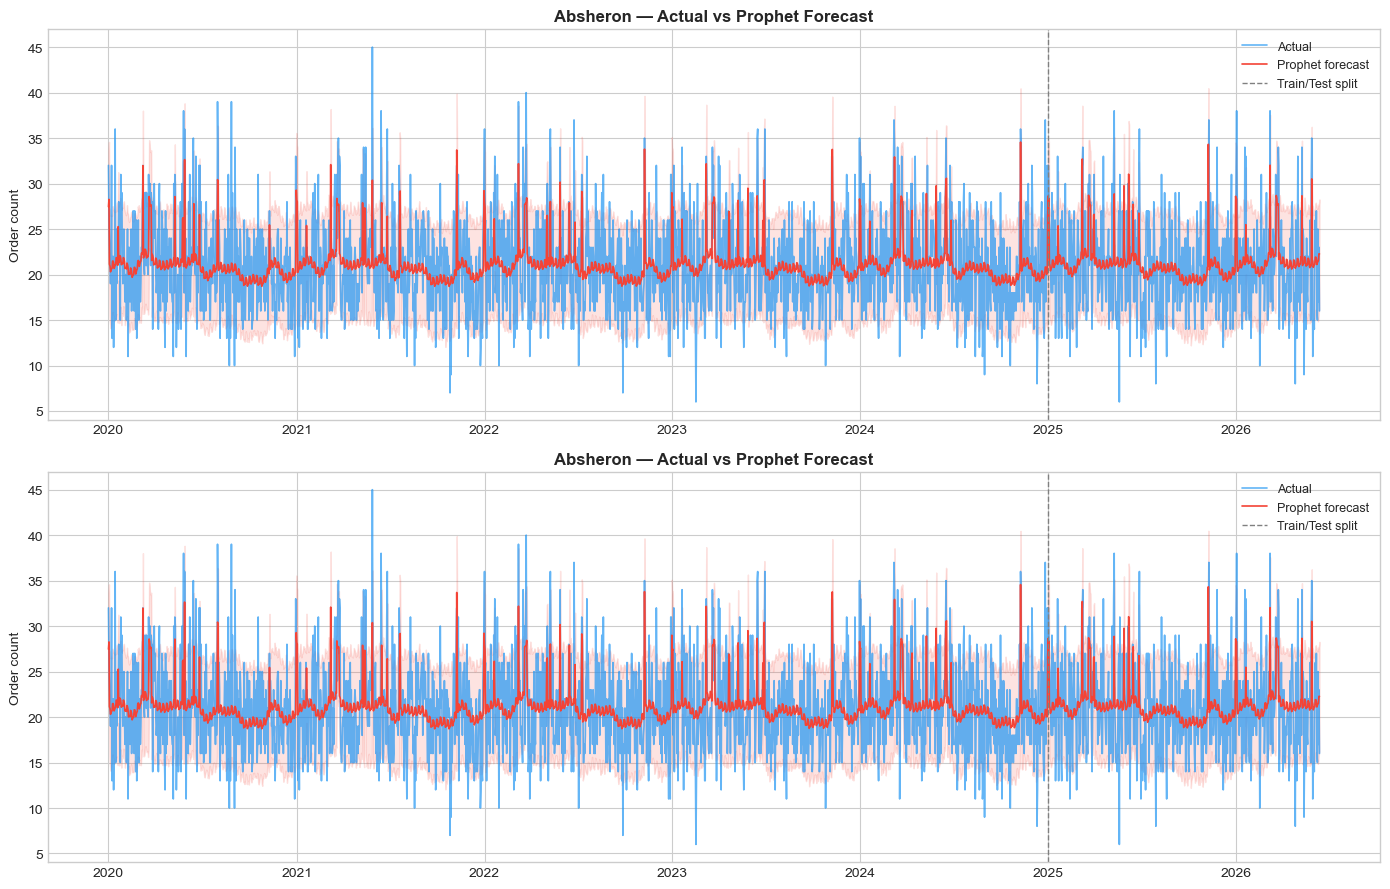

✅ Visualization complete


In [12]:
result_df = pd.concat(all_predictions, ignore_index=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

top_region = metrics_df.index[0]
big_region = 'Absheron' if 'Absheron' in REGIONS else REGIONS[0]

for ax, region in zip(axes, [big_region, top_region]):
    rp = result_df[result_df['region'] == region]
    ax.plot(rp['ds'], rp['y'], label='Actual', color='#2196F3', linewidth=1.2, alpha=0.7)
    ax.plot(rp['ds'], rp['yhat'], label='Prophet forecast', color='#F44336', linewidth=1.2)
    ax.fill_between(rp['ds'], rp['yhat_lower'], rp['yhat_upper'], color='#F44336', alpha=0.15)
    ax.axvline(SPLIT_DATE, color='gray', linestyle='--', linewidth=1, label='Train/Test split')
    ax.set_title(f'{region} — Actual vs Prophet Forecast', fontsize=12, fontweight='bold')
    ax.set_ylabel('Order count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("✅ Visualization complete")


## 8. Save Predictions

`prophet_baseline_predictions.csv` is the deliverable referenced by V-01 (Day 11) — it must contain predictions for every region across the full date range, tagged with `split` (train/test) so downstream comparison code can filter cleanly.

In [13]:
result_df = result_df[['ds', 'region', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'split']]
result_df = result_df.rename(columns={'ds': 'date', 'y': 'actual', 'yhat': 'predicted',
                                       'yhat_lower': 'predicted_lower', 'yhat_upper': 'predicted_upper'})

result_df.to_csv('prophet_baseline_predictions.csv', index=False)

print(f"✅ Saved prophet_baseline_predictions.csv")
print(f"   Rows: {len(result_df):,}")
print(f"   Columns: {list(result_df.columns)}")
print(f"   Regions: {result_df['region'].nunique()}")
print(f"   Date range: {result_df['date'].min().date()} -> {result_df['date'].max().date()}")
result_df.head()


✅ Saved prophet_baseline_predictions.csv
   Rows: 23,550
   Columns: ['date', 'region', 'actual', 'predicted', 'predicted_lower', 'predicted_upper', 'split']
   Regions: 10
   Date range: 2020-01-01 -> 2026-06-12


,date,region,actual,predicted,predicted_lower,predicted_upper,split
0,2020-01-01,Absheron,32.0,27.467724,21.238791,33.642592,train
1,2020-01-02,Absheron,26.0,28.262092,22.512910,34.587797,train
2,2020-01-03,Absheron,23.0,21.110932,15.419759,27.339353,train
3,2020-01-04,Absheron,21.0,20.935843,14.694644,27.220913,train
4,2020-01-05,Absheron,19.0,20.302646,14.094241,26.448713,train


In [14]:
# Also save the per-region metrics table (handy reference for Day 10 model comparison)
metrics_df.reset_index().to_csv('prophet_baseline_metrics.csv', index=False)
print("✅ Saved prophet_baseline_metrics.csv (per-region MAE/RMSE/R²)")


✅ Saved prophet_baseline_metrics.csv (per-region MAE/RMSE/R²)


In [15]:
df = pd.read_csv('prophet_baseline_predictions.csv')
df.region.

,date,region,actual,predicted,predicted_lower,predicted_upper,split
0,2020-01-01,Absheron,32.0,27.467724,21.238791,33.642592,train
1,2020-01-02,Absheron,26.0,28.262092,22.512910,34.587797,train
2,2020-01-03,Absheron,23.0,21.110932,15.419759,27.339353,train
3,2020-01-04,Absheron,21.0,20.935843,14.694644,27.220913,train
4,2020-01-05,Absheron,19.0,20.302646,14.094241,26.448713,train
...,...,...,...,...,...,...,...
23545,2026-06-08,Yevlakh,0.0,1.017319,-0.178943,2.165895,test
23546,2026-06-09,Yevlakh,2.0,1.013140,-0.153869,2.256726,test
23547,2026-06-10,Yevlakh,0.0,1.041108,-0.173277,2.276936,test
23548,2026-06-11,Yevlakh,1.0,1.017074,-0.268527,2.250761,test
